# Installing and setting up environment for using Spark (Java 17, Spark 3.5.1 with Hadoop 3 support, PySpark Python package)

In [ ]:
!java -version

openjdk version "17.0.17" 2025-10-21
OpenJDK Runtime Environment (build 17.0.17+10-Ubuntu-122.04)
OpenJDK 64-Bit Server VM (build 17.0.17+10-Ubuntu-122.04, mixed mode, sharing)


In [16]:
!pip install pyspark
# Create Spark session
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("CloudTechProject").getOrCreate()

spark

# Connecting to Google Drive for accessing datasets

In [ ]:
# mount Google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Importing commonly used functions from PySpark's SQL module, which we will use to perform operations on our dataframe

In [ ]:
# import necessary functions
from pyspark.sql.functions import col, lower, regexp_replace, trim, expr

 # Reading our datasets (Grammy and Spotify)

 # First, we make the data pipeline to get the grammy_group

In [ ]:
# read big data from Google Drive (Records from Grammy and Spotify datasets)
grammy = spark.read.option("quote", '"').option("escape", '"').option("multiLine", True)\
.csv("/content/drive/MyDrive/CloudProj-share/CloudData/grammy_winners.csv", header=True, inferSchema=True)
spotify = spark.read.option("quote", '"').option("escape", '"').option("multiLine", True)\
.csv("/content/drive/MyDrive/CloudProj-share/CloudData/spotify_data.csv", header=True, inferSchema=True)

print("Total records in Grammy Dataset: ", grammy.count())
print("Total records in Spotify Dataset: ", spotify.count())


Total records in Grammy Dataset:  25370
Total records in Spotify Dataset:  1159764


In [ ]:
# checking our Spotify dataset
spotify.show(5)

+-------------+-------------+----------------+--------------------+----------+------------+--------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+--------------+
|spotify_index|  artist_name|      track_name|            track_id|popularity|spotify_year|   genre|danceability|energy|key|loudness|mode|speechiness|acousticness|instrumentalness|liveness|valence|  tempo|duration_ms|time_signature|
+-------------+-------------+----------------+--------------------+----------+------------+--------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+--------------+
|            0|   Jason Mraz| I Won't Give Up|53QF56cjZA9RTuuMZ...|        68|        2012|acoustic|       0.483| 0.303|  4| -10.058|   1|     0.0429|       0.694|             0.0|   0.115|  0.139|133.406|     240166|             3|
|            1|   Jason Mraz|93 Million Miles|1s8tP3jP4GZcyHDsj...| 

In [ ]:
# listing the columns in Spotify dataset
spotify.columns

['spotify_index',
 'artist_name',
 'track_name',
 'track_id',
 'popularity',
 'spotify_year',
 'genre',
 'danceability',
 'energy',
 'key',
 'loudness',
 'mode',
 'speechiness',
 'acousticness',
 'instrumentalness',
 'liveness',
 'valence',
 'tempo',
 'duration_ms',
 'time_signature']

In [ ]:
# checking our Grammy dataset
grammy.show(5)

+------------+-----------+--------------+--------------------+--------------------+--------------------+--------------------+------+--------------------+
|grammy_index|grammy_year|annual_edition|            category|              artist|           producers|       song_or_album|winner|                 url|
+------------+-----------+--------------+--------------------+--------------------+--------------------+--------------------+------+--------------------+
|           0|       2024|            67|Best Boxed Or Spe...|Nick Azinas & Mik...|                NULL|  Half Living Things| false|https://www.gramm...|
|           1|       2024|            67|Best Instrumental...|                NULL|             Strands|             Strands|  true|https://www.gramm...|
|           2|       2024|            67|Best Opera Recording|John Adams, condu...|                NULL|Adams: Girls Of T...| false|https://www.gramm...|
|           3|       2024|            67|Best Classical In...|          Andy

In [ ]:
# check the top n categories with maximum count in Grammy dataset
grammy.groupBy("category").count().orderBy(col("count").desc()).show(10)

+--------------------+-----+
|            category|count|
+--------------------+-----+
|    Song Of The Year|  364|
|  Record Of The Year|  362|
|   Album Of The Year|  348|
|Best Opera Recording|  334|
|    Best Album Notes|  315|
|   Best Country Song|  274|
|     Best New Artist|  268|
|Best Instrumental...|  261|
|Best Chamber Musi...|  243|
|Best Historical A...|  218|
+--------------------+-----+
only showing top 10 rows



In [ ]:
# filter the Grammy dataset for years between [2000,2023] and category == 'Record Of The Year'
filtered_grammy = grammy.filter(
    (col("grammy_year").between(2000, 2023)) &
    (col("category") == "Record Of The Year"))

In [ ]:
# check missing values in song_or_album column of Grammy dataset
count = filtered_grammy.filter(col("song_or_album").isNull()).count()
print(f"nan value of song_or_album count: {count}")


nan value of song_or_album count: 0


# There are 0 missing values for song or album column in Grammy dataset

In [ ]:
# check every years winners count at Grammy's
value_count = filtered_grammy.groupBy("grammy_year").count().orderBy("grammy_year")
value_count.show()


+-----------+-----+
|grammy_year|count|
+-----------+-----+
|       2000|    5|
|       2001|    5|
|       2002|    5|
|       2003|    5|
|       2004|    5|
|       2005|    5|
|       2006|    5|
|       2007|    5|
|       2008|    5|
|       2009|    5|
|       2010|    5|
|       2011|    5|
|       2012|    6|
|       2013|    5|
|       2014|    5|
|       2015|    5|
|       2016|    5|
|       2017|    5|
|       2018|    8|
|       2019|    8|
+-----------+-----+
only showing top 20 rows



In [ ]:
# handle the column song_or_album, remove whitespaces, brackets and text in those brackets mentioned after the song name
# example: xxx (single), xxx (track)
filtered_grammy = filtered_grammy.withColumn("song_or_album",
    trim(regexp_replace(col("song_or_album"), r"\s*\(.+\)$", "")))

In [ ]:
# check the count of Grammy's records after filtering
filtered_grammy.count()

143

In [ ]:
# preparation before merge data: change to lower case; artist name and song/track/album name will be used to merge both datasets
spotify_lower = spotify.withColumn("artist_name", lower(col("artist_name"))) \
                       .withColumn("track_name", lower(col("track_name")))

filtered_grammy_lower = filtered_grammy.withColumn("artist", lower(col("artist"))) \
                                       .withColumn("song_or_album", lower(col("song_or_album")))


In [ ]:
# use artist_name and track_name from spotify to inner merge artist and song_or_album from grammy
merged_inner = spotify_lower.join(
    filtered_grammy_lower,
    (spotify_lower.artist_name == filtered_grammy_lower.artist) &
    (spotify_lower.track_name == filtered_grammy_lower.song_or_album),
    "inner"
)

print ("Number of records after inner merge: ",merged_inner.count())

Number of records after inner merge:  90


In [ ]:
# checking the merging columns values after merging both datasets
merged_inner.select("track_name", "song_or_album", "artist_name", "artist").show()

+--------------------+--------------------+---------------+---------------+
|          track_name|       song_or_album|    artist_name|         artist|
+--------------------+--------------------+---------------+---------------+
|locked out of heaven|locked out of heaven|     bruno mars|     bruno mars|
|            firework|            firework|     katy perry|     katy perry|
|    thinkin bout you|    thinkin bout you|    frank ocean|    frank ocean|
|we are never ever...|we are never ever...|   taylor swift|   taylor swift|
|         radioactive|         radioactive|imagine dragons|imagine dragons|
|         say my name|         say my name|destiny's child|destiny's child|
|              royals|              royals|          lorde|          lorde|
|   thinking out loud|   thinking out loud|     ed sheeran|     ed sheeran|
|       bleeding love|       bleeding love|    leona lewis|    leona lewis|
| all about that bass| all about that bass| meghan trainor| meghan trainor|
|       lose

In [ ]:
# use right merge to get all Grammy Record of the year winners and their Spotify info if present in spotify dataset
merged_right = spotify_lower.join(
    filtered_grammy_lower,
    (spotify_lower.artist_name == filtered_grammy_lower.artist) &
    (spotify_lower.track_name == filtered_grammy_lower.song_or_album),
    "right"
)

In [ ]:
merged_right.show(5)

+-------------+------------+-----------------+--------------------+----------+------------+---------+------------+------+----+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+--------------+------------+-----------+--------------+------------------+-------------+--------------------+--------------------+------+--------------------+
|spotify_index| artist_name|       track_name|            track_id|popularity|spotify_year|    genre|danceability|energy| key|loudness|mode|speechiness|acousticness|instrumentalness|liveness|valence|  tempo|duration_ms|time_signature|grammy_index|grammy_year|annual_edition|          category|       artist|           producers|       song_or_album|winner|                 url|
+-------------+------------+-----------------+--------------------+----------+------------+---------+------------+------+----+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+--------------+----------

In [ ]:
# shapes for both datasets
print("Spotify rows and cols: " ,spotify_lower.count(), len(spotify_lower.columns))
print("Grammy rows and cols: ", filtered_grammy_lower.count(), len(filtered_grammy_lower.columns))

Spotify rows and cols:  1159764 20
Grammy rows and cols:  143 9


In [ ]:
# get unmatched data (Spotify info not found for Grammy record)
un_match = merged_right.filter(col("artist_name").isNull() & col("track_name").isNull())
un_match.count()

54

In [ ]:
# This is mapping between grammy_index and spotify_index, to deal with other unmatched grammy songs

mapping = [
    (999,495913),(1883,506706),(1887,515584),(1888,510000),(1907,487896),
    (2341,433259),(2343,452829),(2770,397305),(3180,321016),(3216,340887),
    (3217,321021),(3240,321017),(3271,406412),(4474,197524),(4497,130176),
    (4536,119695),(5266,72864),(5267,66281),(5358,1147443),(5730,12363),
    (5731,40348),(6156,1076535),(6171,1094145),(6172,1094153),(6173,1047470),
    (6174,264766),(7195,591164),(7768,935552),(7769,930144),(7773,889695),
    (7795,960210),(8373,888932),(8899,862134),(9898,433343),(9901,801524),
    (9902,481739),(10163,759123),(10175,759122),(10605,605428),(11471,674719),
    (11788,120390)
]


mapping_df = spark.createDataFrame(mapping, ["grammy_index", "spotify_index"])


In [ ]:
#  combining grammy data with spotify data horizontally using mapping_df (based on their grammy_index and spotify_index)

merge_unmatched = (
    mapping_df
        .join(filtered_grammy_lower, on="grammy_index", how="left")
        .join(spotify_lower, on="spotify_index", how="left")
)

print(merge_unmatched.count())

41


In [ ]:
# having a look at our initially unmatched data (now horizontally merged using their mapping index)
merge_unmatched.show(5)

+-------------+------------+-----------+--------------+------------------+--------------------+--------------------+--------------------+------+--------------------+-------------------+--------------------+--------------------+----------+------------+-------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+--------------+
|spotify_index|grammy_index|grammy_year|annual_edition|          category|              artist|           producers|       song_or_album|winner|                 url|        artist_name|          track_name|            track_id|popularity|spotify_year|  genre|danceability|energy|key|loudness|mode|speechiness|acousticness|instrumentalness|liveness|valence|  tempo|duration_ms|time_signature|
+-------------+------------+-----------+--------------+------------------+--------------------+--------------------+--------------------+------+--------------------+-------------------+--------------------+----------

In [ ]:
print("Shape of data that matched by song/album and artist name equality comparision: ", merged_inner.count(), len(merged_inner.columns))
print("Shape of data that matched by spotify and grammy index:                        ", merge_unmatched.count(), len(merge_unmatched.columns))

Shape of data that matched by song/album and artist name equality comparision:  90 29
Shape of data that matched by spotify and grammy index:                         41 29


In [ ]:
# vertial merge (union of merged_inner and merged_unmatched)
result = merge_unmatched.unionByName(merged_inner, allowMissingColumns=True)

In [ ]:
# counting our overall rows
result.count()

131

In [ ]:
# checking the result dataset
result.show(5)

+-------------+------------+-----------+--------------+------------------+--------------------+--------------------+--------------------+------+--------------------+-------------------+--------------------+--------------------+----------+------------+-------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+--------------+
|spotify_index|grammy_index|grammy_year|annual_edition|          category|              artist|           producers|       song_or_album|winner|                 url|        artist_name|          track_name|            track_id|popularity|spotify_year|  genre|danceability|energy|key|loudness|mode|speechiness|acousticness|instrumentalness|liveness|valence|  tempo|duration_ms|time_signature|
+-------------+------------+-----------+--------------+------------------+--------------------+--------------------+--------------------+------+--------------------+-------------------+--------------------+----------

In [ ]:
# check duplicate song or album
result.groupBy("song_or_album").count().orderBy("count", ascending=False).show()

+--------------------+-----+
|       song_or_album|count|
+--------------------+-----+
|locked out of heaven|    2|
|    here we go again|    1|
|       all the stars|    1|
|              savage|    1|
|not ready to make...|    1|
|            umbrella|    1|
|i get a kick out ...|    1|
|           i like it|    1|
|love the way you lie|    1|
|let's get it started|    1|
|             shallow|    1|
|        need you now|    1|
|   where is the love|    1|
|        paper planes|    1|
|       blurred lines|    1|
|          the middle|    1|
|      feel good inc.|    1|
|         uptown funk|    1|
|               yeah!|    1|
|       crazy in love|    1|
+--------------------+-----+
only showing top 20 rows



In [ ]:
# show duplicate record
result.filter(col("song_or_album") == "locked out of heaven").show()

+-------------+------------+-----------+--------------+------------------+----------+--------------------+--------------------+------+--------------------+-----------+--------------------+--------------------+----------+------------+-----+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+--------------+
|spotify_index|grammy_index|grammy_year|annual_edition|          category|    artist|           producers|       song_or_album|winner|                 url|artist_name|          track_name|            track_id|popularity|spotify_year|genre|danceability|energy|key|loudness|mode|speechiness|acousticness|instrumentalness|liveness|valence|  tempo|duration_ms|time_signature|
+-------------+------------+-----------+--------------+------------------+----------+--------------------+--------------------+------+--------------------+-----------+--------------------+--------------------+----------+------------+-----+------------+----

In [ ]:
# drop duplicate record for spotify_index=591102
result = result.filter(col("spotify_index") != 591102)

In [ ]:
# check duplicate again
result.groupBy("song_or_album").count().orderBy("count", ascending=False).show()

+--------------------+-----+
|       song_or_album|count|
+--------------------+-----+
|    here we go again|    1|
|       all the stars|    1|
|              savage|    1|
|not ready to make...|    1|
|            umbrella|    1|
|i get a kick out ...|    1|
|           i like it|    1|
|love the way you lie|    1|
|let's get it started|    1|
|             shallow|    1|
|        need you now|    1|
|   where is the love|    1|
|        paper planes|    1|
|       blurred lines|    1|
|          the middle|    1|
|      feel good inc.|    1|
|         uptown funk|    1|
|               yeah!|    1|
|       crazy in love|    1|
|       old town road|    1|
+--------------------+-----+
only showing top 20 rows



In [ ]:
# Save the result to Google Drive
result.write.mode("overwrite").parquet("/content/drive/MyDrive/CloudProj-share/cloud_project_output/grammy_group_parquet")

# Next, we create the data pipeline to get the spotify_group

In [ ]:
# Parsing the dataset with special options because the data is messy as text columns contain ""
spotify = spark.read.option("quote", '"').option("escape", '"').option("multiLine", True)\
.csv("/content/drive/MyDrive/CloudProj-share/CloudData/spotify_data.csv", header=True, inferSchema=True)

# Default/Simple parsing of same Spotify dataset
spotify_without_dealquotation = spark.read.csv("/content/drive/MyDrive/CloudProj-share/CloudData/spotify_data.csv", header=True, inferSchema=True)

In [ ]:
from pyspark.sql.window import Window
from pyspark.sql.functions import col, asc, desc, row_number, length, regexp_extract
from pyspark.sql.functions import when

In [ ]:
spotify.printSchema()

root
 |-- spotify_index: integer (nullable = true)
 |-- artist_name: string (nullable = true)
 |-- track_name: string (nullable = true)
 |-- track_id: string (nullable = true)
 |-- popularity: integer (nullable = true)
 |-- spotify_year: integer (nullable = true)
 |-- genre: string (nullable = true)
 |-- danceability: double (nullable = true)
 |-- energy: double (nullable = true)
 |-- key: integer (nullable = true)
 |-- loudness: double (nullable = true)
 |-- mode: integer (nullable = true)
 |-- speechiness: double (nullable = true)
 |-- acousticness: double (nullable = true)
 |-- instrumentalness: double (nullable = true)
 |-- liveness: double (nullable = true)
 |-- valence: double (nullable = true)
 |-- tempo: double (nullable = true)
 |-- duration_ms: integer (nullable = true)
 |-- time_signature: integer (nullable = true)



# Messy Data: on taking the unique of spotify_year 2000-2023, we find that the results are not as expected, we are getting mixed columns instead of distinct spotify_year because of presence of quotes in the string data

### Below we are showing how to deal with this problem

In [ ]:
# before we handle the problem, let's check the column spotify_year which shows messy results
spotify_without_dealquotation.select('spotify_year').distinct().show(20,truncate=False)

+----------------------+
|spotify_year          |
+----------------------+
|007VTPx3UOezmy7xWsrquW|
|6zgWk7VmYihSrU1UDrSThC|
|4ir1OyDVCLBFXePjhiIFEK|
|7                     |
|2QRL3aEqAyKCc88yfoEq3g|
|51                    |
|1QrtVtu28d9LsGQD56sqL3|
|3uZBqptJfTzUaF6ZVP27Ge|
|5MlzjVzTnolUIah7beG87r|
| Floßhilde)"          |
|1aLs8G7GNBWLloglhNP0Nd|
|15                    |
|2jwG0ipR11UNSI9XUzusQ0|
|54                    |
|2016                  |
|0orJChfDosI9HpzPVomcVS|
|48QL3WyaTFo6864EUiGiRQ|
|2012                  |
|2020                  |
|11                    |
+----------------------+
only showing top 20 rows



In [ ]:
# we can see spotify_year column is returning string, let's check the structure of our dataset
spotify_without_dealquotation.printSchema()

root
 |-- spotify_index: integer (nullable = true)
 |-- artist_name: string (nullable = true)
 |-- track_name: string (nullable = true)
 |-- track_id: string (nullable = true)
 |-- popularity: string (nullable = true)
 |-- spotify_year: string (nullable = true)
 |-- genre: string (nullable = true)
 |-- danceability: string (nullable = true)
 |-- energy: string (nullable = true)
 |-- key: string (nullable = true)
 |-- loudness: string (nullable = true)
 |-- mode: string (nullable = true)
 |-- speechiness: string (nullable = true)
 |-- acousticness: string (nullable = true)
 |-- instrumentalness: string (nullable = true)
 |-- liveness: string (nullable = true)
 |-- valence: double (nullable = true)
 |-- tempo: double (nullable = true)
 |-- duration_ms: double (nullable = true)
 |-- time_signature: double (nullable = true)



# Observations:

*   spotify_year column is of string type
*   track_name splits into more columns because we did not escape quotation marks
*   Example 1:
    *   8559 actual track name: Don Giovanni, ossia Il dissoluto punito, K.527 / Act 2: "Don Giovanni, a cenar teco m'invitasti"
    *   In pyspark trackname: "Don Giovanni, ossia Il dissoluto punito, K.527 / Act 2: ""Don Giovanni
    *   In pyspark track_id : a cenar teco m'invitasti"""    
*   Example 2:
    *   8636 actual track name: All-night Vigil, Op. 37, "Vespers": Hail, O Virgin Mother (Ave Maria)
    *   In pyspark trackname: "All-night Vigil, Op. 37, ""Vespers"": Hail
    *   In pyspark track_id: O Virgin Mother (Ave Maria)"

Which implies:
*   origin content: ABC: "DEF,GH "
*   in csv :     "ABC: ""DEF,GH"""


In [ ]:
# Have a look at the result because of this issue
spotify_bad = spotify_without_dealquotation.filter(
    (regexp_extract(col("spotify_year"), r'^\d{4}$', 0) == "")
)

spotify_bad.show(10, truncate=False)


+-------------+------------------------+-------------------------------------------------------------------------------+-------------------------------+----------------------------+----------------------+-------------+----------------------+---------+------+---------+-------+-----------+------------+----------------+--------+-------+------+-----------+--------------+
|spotify_index|artist_name             |track_name                                                                     |track_id                       |popularity                  |spotify_year          |genre        |danceability          |energy   |key   |loudness |mode   |speechiness|acousticness|instrumentalness|liveness|valence|tempo |duration_ms|time_signature|
+-------------+------------------------+-------------------------------------------------------------------------------+-------------------------------+----------------------------+----------------------+-------------+----------------------+---------+------+--

# On adding this code during read csv file, the issue will be fixed
+ .option("quote", '"').option("escape", '"').option("multiLine", True)

# Now, let's continue with the pipeline

In [ ]:
spotify.show(5)

+-------------+-------------+----------------+--------------------+----------+------------+--------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+--------------+
|spotify_index|  artist_name|      track_name|            track_id|popularity|spotify_year|   genre|danceability|energy|key|loudness|mode|speechiness|acousticness|instrumentalness|liveness|valence|  tempo|duration_ms|time_signature|
+-------------+-------------+----------------+--------------------+----------+------------+--------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+--------------+
|            0|   Jason Mraz| I Won't Give Up|53QF56cjZA9RTuuMZ...|        68|        2012|acoustic|       0.483| 0.303|  4| -10.058|   1|     0.0429|       0.694|             0.0|   0.115|  0.139|133.406|     240166|             3|
|            1|   Jason Mraz|93 Million Miles|1s8tP3jP4GZcyHDsj...| 

In [ ]:
topn = 100

In [ ]:
# check distinct year from 2000-2023
spotify.select("spotify_year").distinct().orderBy("spotify_year").show(100)

+------------+
|spotify_year|
+------------+
|        2000|
|        2001|
|        2002|
|        2003|
|        2004|
|        2005|
|        2006|
|        2007|
|        2008|
|        2009|
|        2010|
|        2011|
|        2012|
|        2013|
|        2014|
|        2015|
|        2016|
|        2017|
|        2018|
|        2019|
|        2020|
|        2021|
|        2022|
|        2023|
+------------+



In [ ]:
# partitionBy spotify_year, sort by popularity and get every year's top n songs

window_spec = Window.partitionBy("spotify_year").orderBy(col("popularity").desc())

spotify_group = (
    spotify
    .withColumn("rn", row_number().over(window_spec))
    .filter(col("rn") <= topn)
    .drop("rn")
)

In [ ]:
# the songs in this group are our target -- most popular songs in spotify
spotify_group.count()

2400

In [ ]:
spotify_group.show(10)

+-------------+--------------+--------------------+--------------------+----------+------------+--------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+--------------+
|spotify_index|   artist_name|          track_name|            track_id|popularity|spotify_year|   genre|danceability|energy|key|loudness|mode|speechiness|acousticness|instrumentalness|liveness|valence|  tempo|duration_ms|time_signature|
+-------------+--------------+--------------------+--------------------+----------+------------+--------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+--------------+
|       645970|        Eminem| The Real Slim Shady|3yfqSUWxFvZELEM4P...|        86|        2000| hip-hop|       0.949| 0.661|  5|  -4.244|   0|     0.0572|      0.0302|             0.0|  0.0454|   0.76|104.504|     284200|             4|
|       645972|        Eminem|                St

In [ ]:
# read grammy_group parquet (that we saved from earlier steps after preprocessing Grammy dataset) from google drive
grammy_group = spark.read.parquet("/content/drive/MyDrive/CloudProj-share/cloud_project_output/grammy_group_parquet")

In [ ]:
grammy_group.show(5)

+-------------+------------+-----------+--------------+------------------+---------------+--------------------+--------------------+------+--------------------+---------------+--------------------+--------------------+----------+------------+-------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+--------------+
|spotify_index|grammy_index|grammy_year|annual_edition|          category|         artist|           producers|       song_or_album|winner|                 url|    artist_name|          track_name|            track_id|popularity|spotify_year|  genre|danceability|energy|key|loudness|mode|speechiness|acousticness|instrumentalness|liveness|valence|  tempo|duration_ms|time_signature|
+-------------+------------+-----------+--------------+------------------+---------------+--------------------+--------------------+------+--------------------+---------------+--------------------+--------------------+----------+-----

In [ ]:
# just filter and keep the columns that we have in grammy_winner
filter_grammy_group = grammy_group.select(
    "grammy_index","grammy_year","annual_edition","category",
    "artist","producers","song_or_album","winner","url","spotify_index"
)

In [ ]:
# merge spotify_group and filter_grammy_group using spotify_index
spotify_group_merged = spotify_group.join(
    filter_grammy_group,
    on="spotify_index",
    how="left"
)
spotify_group_merged.count()

2400

In [ ]:
spotify_group_merged.show(5)

+-------------+--------------+--------------------+--------------------+----------+------------+-------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+--------------+------------+-----------+--------------+------------------+-------+--------------------+-------------+------+--------------------+
|spotify_index|   artist_name|          track_name|            track_id|popularity|spotify_year|  genre|danceability|energy|key|loudness|mode|speechiness|acousticness|instrumentalness|liveness|valence|  tempo|duration_ms|time_signature|grammy_index|grammy_year|annual_edition|          category| artist|           producers|song_or_album|winner|                 url|
+-------------+--------------+--------------------+--------------------+----------+------------+-------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+--------------+------------+-----------+-----

In [ ]:
# find overlap between two group
overlap_song = spotify_group_merged.filter(col("grammy_index").isNotNull())
overlap_song.count()

74

In [ ]:
# saving the result to Google Drive
spotify_group_merged.write.mode("overwrite").parquet("/content/drive/MyDrive/CloudProj-share/cloud_project_output/spotify_group_parquet")

# Here, we finished our data pipeline part
# Then, reading the two parquet saved and create visualization using Pandas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets

In [ ]:
spotify_popular_group = pd.read_parquet("/content/drive/MyDrive/CloudProj-share/cloud_project_output/spotify_group_parquet")
grammy_group = pd.read_parquet("/content/drive/MyDrive/CloudProj-share/cloud_project_output/grammy_group_parquet")
spotify_general_group=pd.read_csv('/content/drive/MyDrive/CloudProj-share/CloudData/spotify_data.csv')

In [ ]:
spotify_popular_group.head()

,spotify_index,artist_name,track_name,track_id,popularity,spotify_year,genre,danceability,energy,key,...,time_signature,grammy_index,grammy_year,annual_edition,category,artist,producers,song_or_album,winner,url
0,645970,Eminem,The Real Slim Shady,3yfqSUWxFvZELEM4PmlwIR,86,2000,hip-hop,0.949,0.661,5,...,4,NaN,NaN,NaN,None,None,None,None,None,None
1,645972,Eminem,Stan,3UmaczJpikHgJFyBTAJVoz,82,2000,hip-hop,0.780,0.768,6,...,4,NaN,NaN,NaN,None,None,None,None,None,None
2,645971,Outkast,Ms. Jackson,0I3q5fE6wg7LIfHGngUTnV,80,2000,hip-hop,0.843,0.806,4,...,4,11037.0,2001.0,44.0,Record Of The Year,outkast,"Earthtone III, producer; John Frye & Neal H. P...",ms. jackson,False,https://www.grammy.com/awards/44th-annual-gram...
3,630466,Shaggy,It Wasn't Me,3WkibOpDF7cQ5xntM1epyf,77,2000,dance,0.853,0.606,0,...,4,NaN,NaN,NaN,None,None,None,None,None,None
4,630467,Britney Spears,Oops!...I Did It Again,6naxalmIoLFWR0siv8dnQQ,77,2000,dance,0.751,0.834,1,...,4,NaN,NaN,NaN,None,None,None,None,None,None


In [ ]:
grammy_group.head()

,spotify_index,grammy_index,grammy_year,annual_edition,category,artist,producers,song_or_album,winner,url,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,66281,5267,2013,56,Record Of The Year,robin thicke featuring t.i. & pharrell,"Pharrell, producer; Andrew Coleman & Tony Mase...",blurred lines,False,https://www.grammy.com/awards/56th-annual-gram...,...,-4.756,1,0.0411,0.00334,0.000008,0.0759,0.843,119.993,263827,4
1,197524,4474,2015,58,Record Of The Year,mark ronson featuring bruno mars,None,uptown funk,True,https://www.grammy.com/awards/58th-annual-gram...,...,-7.223,1,0.0824,0.00801,0.000082,0.0344,0.928,114.988,269667,4
2,264766,6174,2010,53,Record Of The Year,lady antebellum,None,need you now,True,https://www.grammy.com/awards/53rd-annual-gram...,...,-5.561,1,0.0332,0.08150,0.000040,0.1420,0.350,107.925,233267,4
3,321016,3180,2018,61,Record Of The Year,lady gaga & bradley cooper,"Lady Gaga & Benjamin Rice, producers; Brandon ...",shallow,False,https://www.grammy.com/awards/61st-annual-gram...,...,-6.362,1,0.0308,0.37100,0.000000,0.2310,0.323,95.799,215733,4
4,321017,3240,2018,61,Record Of The Year,"zedd, maren morris & grey","Grey, Monsters & Strangerz & Zedd, producers; ...",the middle,False,https://www.grammy.com/awards/61st-annual-gram...,...,-3.061,1,0.0449,0.17100,0.000000,0.1120,0.437,107.010,184732,4


In [ ]:
grammy_group.shape

(130, 29)

In [ ]:
spotify_popular_group.shape

(2400, 29)

In [ ]:
spotify_general_group.shape

(1159764, 20)

In [ ]:
spotify_popular_group.columns

Index(['spotify_index', 'artist_name', 'track_name', 'track_id', 'popularity',
       'spotify_year', 'genre', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms', 'time_signature', 'grammy_index',
       'grammy_year', 'annual_edition', 'category', 'artist', 'producers',
       'song_or_album', 'winner', 'url'],
      dtype='object')

In [ ]:
spotify_popular_group.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 29 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   spotify_index     2400 non-null   int32  
 1   artist_name       2400 non-null   object 
 2   track_name        2400 non-null   object 
 3   track_id          2400 non-null   object 
 4   popularity        2400 non-null   int32  
 5   spotify_year      2400 non-null   int32  
 6   genre             2400 non-null   object 
 7   danceability      2400 non-null   float64
 8   energy            2400 non-null   float64
 9   key               2400 non-null   int32  
 10  loudness          2400 non-null   float64
 11  mode              2400 non-null   int32  
 12  speechiness       2400 non-null   float64
 13  acousticness      2400 non-null   float64
 14  instrumentalness  2400 non-null   float64
 15  liveness          2400 non-null   float64
 16  valence           2400 non-null   float64


# Plot a line Graph

In [ ]:
# get the mean and median value by year for each of the 3 groups
'''
'popularity', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'duration_ms','time_signature'
'''
target_feature=['popularity', 'danceability', 'energy','speechiness',
        'acousticness', 'instrumentalness', 'liveness','valence', 'duration_ms']

spotify_popular_data_mean= spotify_popular_group.groupby('spotify_year')[target_feature].mean()
spotify_popular_data_median= spotify_popular_group.groupby('spotify_year')[target_feature].median()

grammy_data_mean= grammy_group.groupby('spotify_year')[target_feature].mean()
grammy_data_median= grammy_group.groupby('spotify_year')[target_feature].median()

spotify_general_data_mean= spotify_general_group.groupby('spotify_year')[target_feature].mean()
spotify_general_data_median= spotify_general_group.groupby('spotify_year')[target_feature].mean()


In [ ]:
grammy_data_mean.columns

Index(['popularity', 'danceability', 'energy', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'duration_ms'],
      dtype='object')

In [ ]:
# draw lineplot to compare the three groups for given feature mean or median value per year
sns.set_style("whitegrid")
sns.set_context("talk")

def plot_feature(stat_type, feature):
    plt.figure(figsize=(12,5))

    if stat_type == 'Mean':
        grammy_df = grammy_data_mean
        pop_df = spotify_popular_data_mean
        general_df = spotify_general_data_mean
    else:
        grammy_df = grammy_data_median
        pop_df = spotify_popular_data_median
        general_df = spotify_general_data_median

    sns.lineplot(x='spotify_year', y=feature, data=grammy_df,
                 label='Critically Acclaimed',linewidth=2.5, marker='o')
    sns.lineplot(x='spotify_year', y=feature, data=pop_df,
                 label='Listener Hit',linewidth=2.5, marker='s')
    sns.lineplot(x='spotify_year', y=feature, data=general_df,
                 label='General Population',linewidth=2.5, marker='^')

    plt.xlabel('Year', fontsize=14)
    plt.ylabel(feature, fontsize=14)
    plt.title(f'{stat_type} of {feature} per Year (2000-2023)', fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.7)
    years = sorted(grammy_group['spotify_year'].unique())
    plt.xticks(years, rotation=45)
    plt.legend(fontsize=9, loc='best')
    plt.tight_layout()
    plt.show()


stat_widget = widgets.Dropdown(
    options=['Mean', 'Median'],
    value='Mean',
    description='Statistic:',
    style={'description_width': '120px'}
)

feature_widget = widgets.Dropdown(
    options=target_feature,value='valence',
    description='Feature:',
    style={'description_width': '120px'}
)

widgets.interact(
    plot_feature,
    stat_type=stat_widget,
    feature=feature_widget
)


interactive(children=(Dropdown(description='Statistic:', options=('Mean', 'Median'), style=DescriptionStyle(de…

<function __main__.plot_feature(stat_type, feature)>

# Plot a bar graph

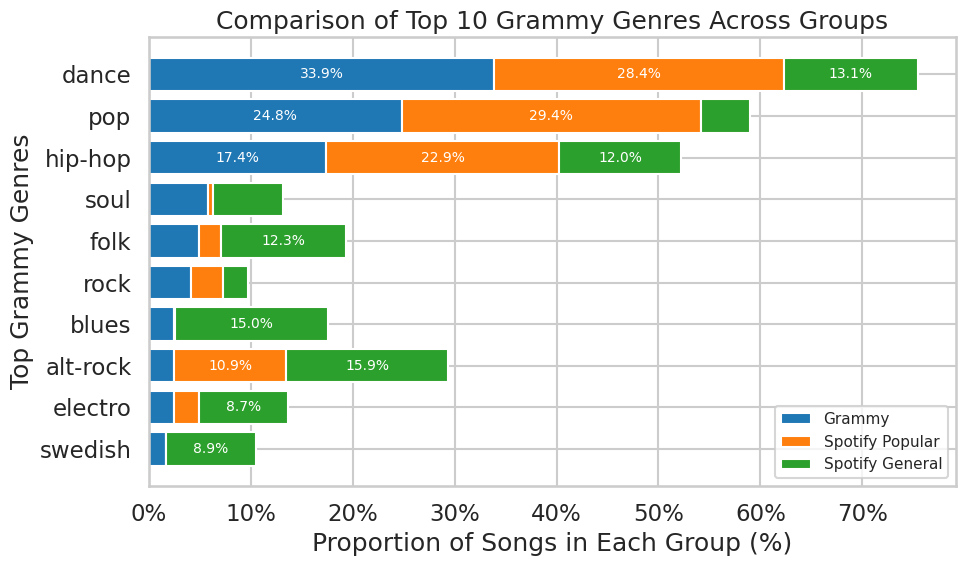

In [ ]:
sns.set_style("whitegrid")
sns.set_context("talk")

def plot_topn_grammy_genres(grammy, popular, general, topn=7):
    # get top genres from grammy
    grammy_counts = grammy['genre'].value_counts().head(topn)
    top_genres = grammy_counts.sort_values(ascending=True).index.tolist()

    # calculate ratio per group
    def get_ratio(df):
        counts = df[df['genre'].isin(top_genres)]['genre'].value_counts()
        ratio = (counts / counts.sum()).reindex(top_genres, fill_value=0)
        return ratio.tolist()

    grammy_ratio = get_ratio(grammy)
    popular_ratio = get_ratio(popular)
    general_ratio = get_ratio(general)

    # plot
    plt.figure(figsize=(10,6))
    colors = ['#1f77b4','#ff7f0e','#2ca02c']
    bottoms = [0]*topn

    for vals, color, label in zip([grammy_ratio, popular_ratio, general_ratio],
                                  colors,
                                  ['Grammy','Spotify Popular','Spotify General']):
        plt.barh(top_genres, vals, left=bottoms, color=color, label=label)
        # show value on bar
        for i, v in enumerate(vals):
            if v >= 0.07:
                plt.text(bottoms[i]+v/2, i, f"{v*100:.1f}%", ha='center', va='center', color='white', fontsize=10)
        bottoms = [b+v for b,v in zip(bottoms, vals)]

    plt.xlabel("Proportion of Songs in Each Group (%)")
    plt.ylabel("Top Grammy Genres")
    plt.title(f'Comparison of Top {topn} Grammy Genres Across Groups')
    plt.gca().xaxis.set_major_formatter(lambda x, _: f"{int(x*100)}%")
    plt.legend(fontsize=11, title_fontsize=12)
    plt.tight_layout()
    plt.show()


plot_topn_grammy_genres(grammy_group, spotify_popular_group, spotify_general_group, topn=10)